In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\rajiv\OneDrive\Desktop\FMCG-Food-Flavor-Analytics-Project\data
['inventory_data.csv', 'product_data.csv', 'Sales_data.csv']


In [3]:
sales = pd.read_csv("sales_data.csv")
products = pd.read_csv("product_data.csv")
inventory = pd.read_csv("inventory_data.csv")

In [4]:
print("Sales Data")
print(sales.head())

print("\nProduct Data")
print(products.head())

print("\nInventory Data")
print(inventory.head())

Sales Data
  Order_ID        Date Product_ID     Product_Name   Category Region  \
0       O1  2025-01-01       P101     Black Pepper     Spices  North   
1       O2  2025-01-02       P102    Chilli Powder     Spices  South   
2       O3  2025-01-03       P103  Turmeric Powder     Spices   East   
3       O4  2025-01-04       P104      Cumin Seeds     Spices   West   
4       O5  2025-01-05       P105    BBQ Seasoning  Seasoning  North   

   Sales_Quantity  Unit_Price  Total_Sales  Cost_Price  Profit  
0              10         200         2000         120     800  
1              15         150         2250          90     900  
2              12         180         2160         110     840  
3               8         220         1760         140     640  
4              20         250         5000         160    1800  

Product Data
  Product_ID     Product_Name   Category Sub_Category  Unit_Cost  \
0       P101     Black Pepper     Spices        Whole        120   
1       P102    

In [5]:
print(sales.columns)
print(products.columns)
print(inventory.columns)

Index(['Order_ID', 'Date', 'Product_ID', 'Product_Name', 'Category', 'Region',
       'Sales_Quantity', 'Unit_Price', 'Total_Sales', 'Cost_Price', 'Profit'],
      dtype='object')
Index(['Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Unit_Cost',
       'Shelf_Life_Days'],
      dtype='object')
Index(['Product_ID', 'Warehouse_Region', 'Stock_Available', 'Reorder_Level',
       'Stock_Status', 'Last_Replenished_Date'],
      dtype='object')


In [6]:
print("Sales Missing Values")
print(sales.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

print("\nInventory Missing Values")
print(inventory.isnull().sum())

Sales Missing Values
Order_ID          0
Date              0
Product_ID        0
Product_Name      0
Category          0
Region            0
Sales_Quantity    0
Unit_Price        0
Total_Sales       0
Cost_Price        0
Profit            0
dtype: int64

Products Missing Values
Product_ID         0
Product_Name       0
Category           0
Sub_Category       0
Unit_Cost          0
Shelf_Life_Days    0
dtype: int64

Inventory Missing Values
Product_ID               0
Warehouse_Region         0
Stock_Available          0
Reorder_Level            0
Stock_Status             0
Last_Replenished_Date    0
dtype: int64


In [7]:
print("Sales Shape:", sales.shape)
print("Products Shape:", products.shape)
print("Inventory Shape:", inventory.shape)

Sales Shape: (10, 11)
Products Shape: (10, 6)
Inventory Shape: (10, 6)


In [8]:
print("Total Revenue:", sales['Total_Sales'].sum())
print("Total Profit:", sales['Profit'].sum())
print("Total Quantity Sold:", sales['Sales_Quantity'].sum())

Total Revenue: 38170
Total Profit: 14380
Total Quantity Sold: 174


In [9]:
top_products = sales.groupby('Product_Name')['Total_Sales'].sum().sort_values(ascending=False)

print(top_products.head(10))

Product_Name
Soy Sauce          7500
Tomato Ketchup     5400
BBQ Seasoning      5000
Mustard Sauce      4840
Italian Herbs      4320
Garlic Powder      2940
Chilli Powder      2250
Turmeric Powder    2160
Black Pepper       2000
Cumin Seeds        1760
Name: Total_Sales, dtype: int64


In [10]:
category_sales = sales.groupby('Category')['Total_Sales'].sum()

print(category_sales)

Category
Condiments    17740
Seasoning     12260
Spices         8170
Name: Total_Sales, dtype: int64


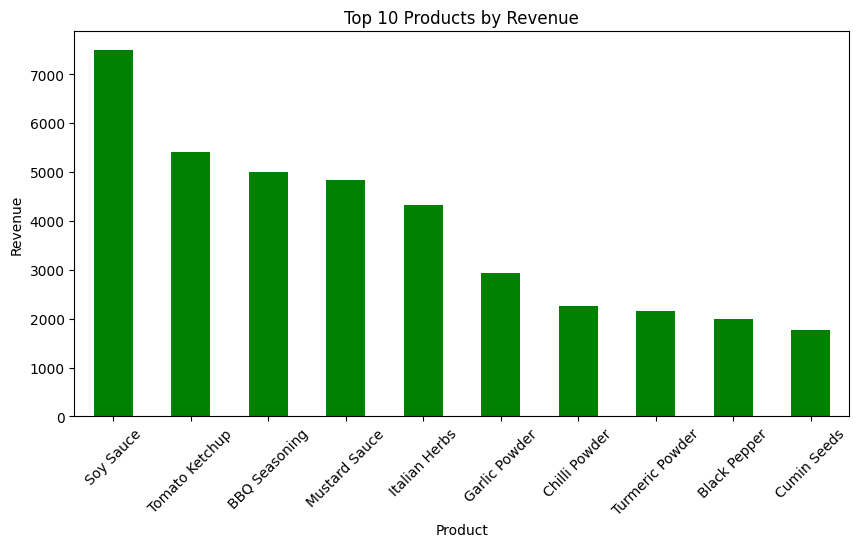

In [11]:
plt.figure(figsize=(10,5))

top_products.head(10).plot(kind='bar', color='green')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

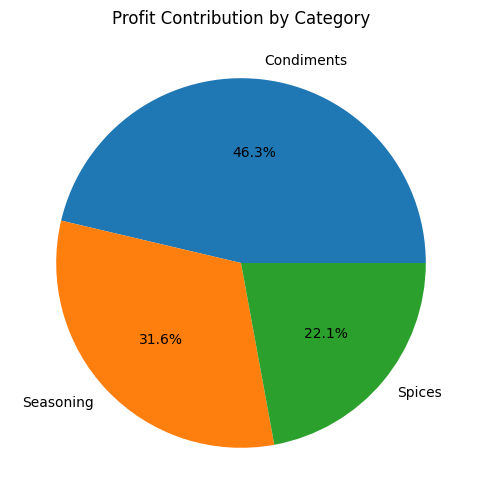

In [12]:
profit_category = sales.groupby('Category')['Profit'].sum()

profit_category.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Profit Contribution by Category")
plt.ylabel("")

plt.show()

In [13]:
print("Total Stock Available:",
      inventory['Stock_Available'].sum())

print("Average Stock Level:",
      inventory['Stock_Available'].mean())

print("Low Stock Products:")
print(inventory[inventory['Stock_Status']=="Low Stock"])

Total Stock Available: 900
Average Stock Level: 90.0
Low Stock Products:
  Product_ID Warehouse_Region  Stock_Available  Reorder_Level Stock_Status  \
1       P102            South               40             60    Low Stock   
3       P104             West               30             40    Low Stock   
7       P108             West               60             80    Low Stock   

  Last_Replenished_Date  
1            2025-01-08  
3            2025-01-07  
7            2025-01-09  


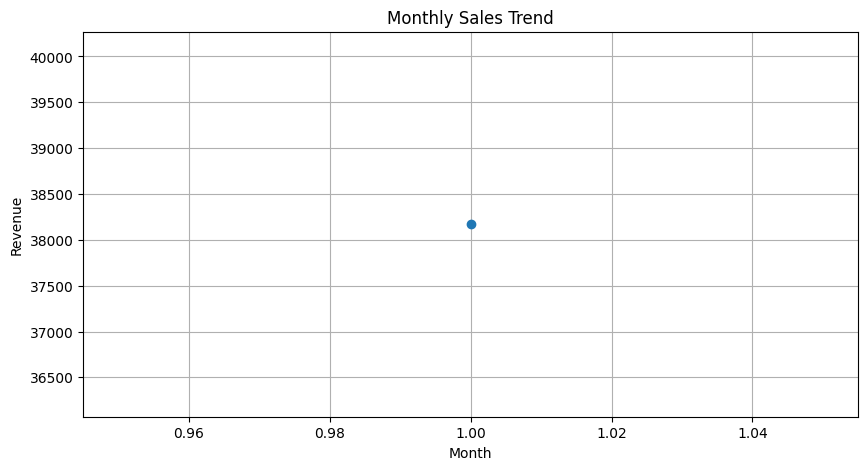

In [14]:
sales['Date'] = pd.to_datetime(sales['Date'])

monthly_sales = sales.groupby(
    sales['Date'].dt.month
)['Total_Sales'].sum()

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

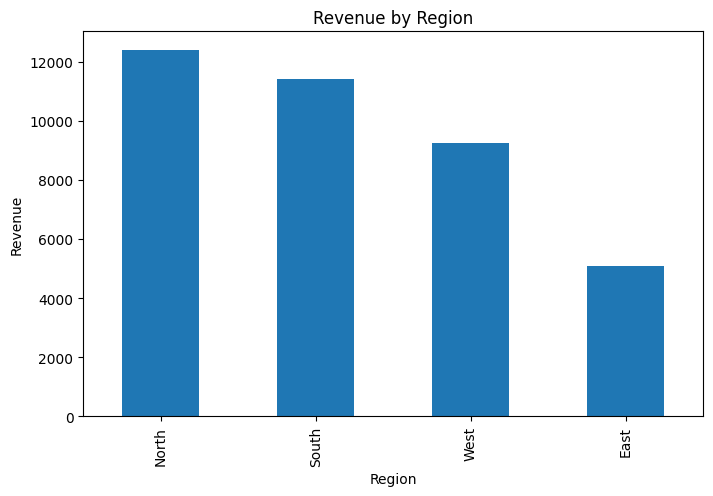

In [15]:
region_sales = sales.groupby(
    'Region'
)['Total_Sales'].sum().sort_values(
    ascending=False
)

region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.show()

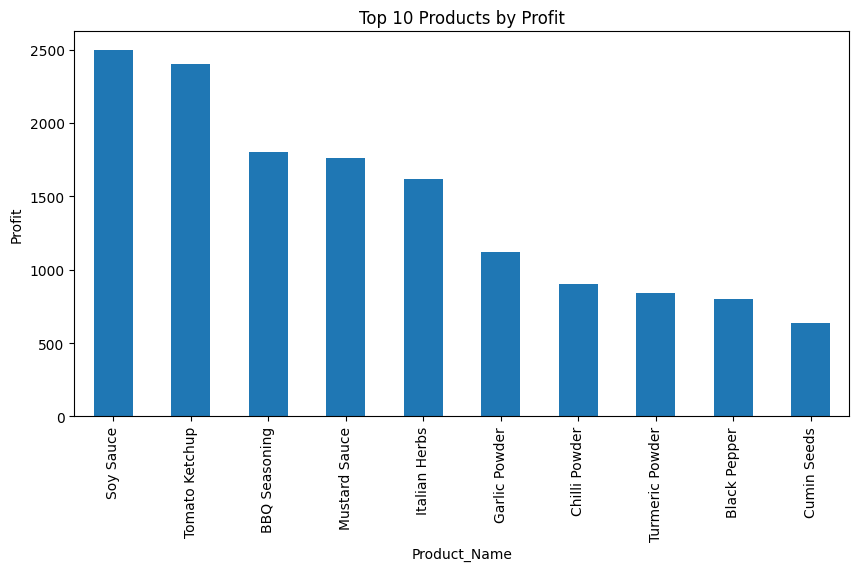

In [16]:
top_profit = sales.groupby(
    'Product_Name'
)['Profit'].sum().sort_values(
    ascending=False
)

top_profit.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Products by Profit")
plt.ylabel("Profit")

plt.show()

In [17]:
df = sales.merge(
    products,
    on='Product_ID',
    how='left'
)

df = df.merge(
    inventory,
    on='Product_ID',
    how='left'
)

df.head()

,Order_ID,Date,Product_ID,Product_Name_x,Category_x,Region,Sales_Quantity,Unit_Price,Total_Sales,Cost_Price,...,Product_Name_y,Category_y,Sub_Category,Unit_Cost,Shelf_Life_Days,Warehouse_Region,Stock_Available,Reorder_Level,Stock_Status,Last_Replenished_Date
0,O1,2025-01-01,P101,Black Pepper,Spices,North,10,200,2000,120,...,Black Pepper,Spices,Whole,120,365,North,120,50,In Stock,2025-01-10
1,O2,2025-01-02,P102,Chilli Powder,Spices,South,15,150,2250,90,...,Chilli Powder,Spices,Powder,90,300,South,40,60,Low Stock,2025-01-08
2,O3,2025-01-03,P103,Turmeric Powder,Spices,East,12,180,2160,110,...,Turmeric Powder,Spices,Powder,110,400,East,80,50,In Stock,2025-01-09
3,O4,2025-01-04,P104,Cumin Seeds,Spices,West,8,220,1760,140,...,Cumin Seeds,Spices,Whole,140,500,West,30,40,Low Stock,2025-01-07
4,O5,2025-01-05,P105,BBQ Seasoning,Seasoning,North,20,250,5000,160,...,BBQ Seasoning,Seasoning,Blend,160,240,North,150,70,In Stock,2025-01-11


In [18]:
df['Inventory_Value'] = (
    df['Stock_Available']
    * df['Unit_Cost']
)

print(
    "Total Inventory Value:",
    df['Inventory_Value'].sum()
)

Total Inventory Value: 117100


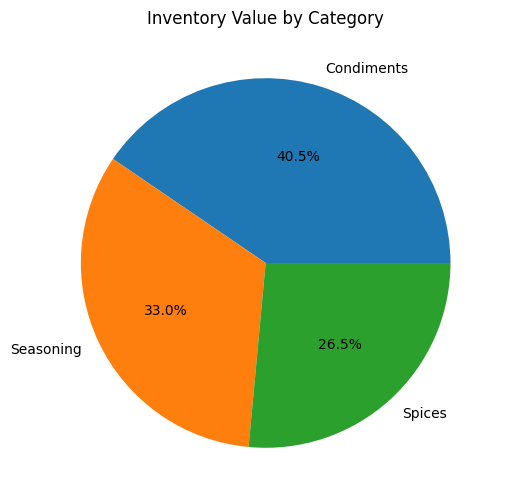

In [19]:
inventory_category = df.groupby(
    'Category_x'
)['Inventory_Value'].sum()

inventory_category.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title(
    "Inventory Value by Category"
)

plt.ylabel("")

plt.show()

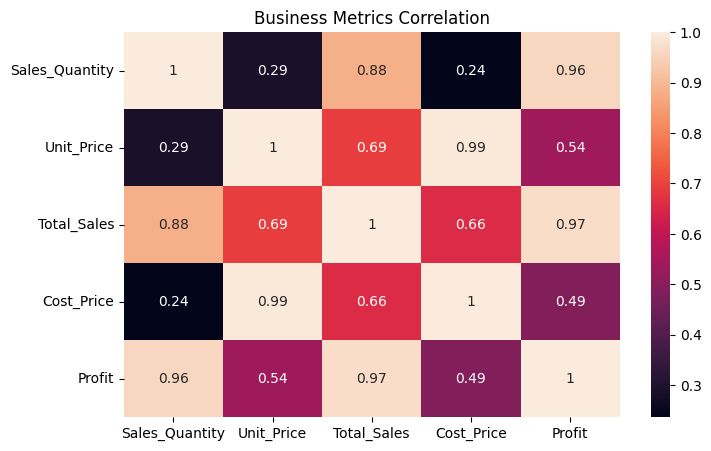

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(
    sales[
        [
            'Sales_Quantity',
            'Unit_Price',
            'Total_Sales',
            'Cost_Price',
            'Profit'
        ]
    ].corr(),
    annot=True
)

plt.title(
    "Business Metrics Correlation"
)

plt.show()

In [22]:
future_months = pd.DataFrame({
    'Date':[13,14,15]
})

forecast = model.predict(future_months)

print(forecast)

[38170. 38170. 38170.]


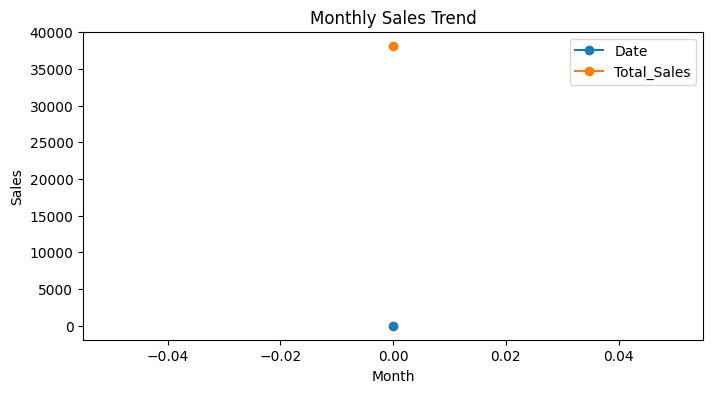

In [23]:
monthly.plot(kind='line', marker='o', figsize=(8,4))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()